# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** [A.A. Jaya Kesuma Wardana]
- **Email:** [cdcc014d6y2870@student.devacademy.id]
- **ID Dicoding:** [CDCC014D6Y2870]

## Menentukan Pertanyaan Bisnis

- Berapa besar dampak kondisi cuaca terhadap jumlah penyewaan sepeda, dan pada kondisi cuaca apa permintaan mencapai titik tertinggi selama periode pengamatan?
- Kapan periode waktu dengan permintaan penyewaan sepeda tertinggi berdasarkan hari dan jam, serta bagaimana pola ini dapat dimanfaatkan untuk meningkatkan efisiensi operasional?
- Berapa perbandingan total penyewaan sepeda antara hari kerja dan hari libur?
- Bagaimana komposisi profil pengguna pada sistem ini, dan sejauh mana perbedaan kontribusi antara pengguna terdaftar (registered) dibandingkan pengguna umum (casual) terhadap total penyewaan?

## Import Semua Packages/Library yang Digunakan

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [4]:
# Load Data day.csv #

day_df = pd.read_csv('day.csv')
day_df.head()



,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Pengguna sepeda didominasi oleh pengguna terdaftar (registered), dengan jumlah yang jauh lebih tinggi dibandingkan pengguna kasual
- Jumlah penyewaan sepeda meningkat secara signifikan pada hari kerja dibandingkan akhir pekan
- Jumlah penyewaan sepeda lebih tinggi pada kondisi cuaca cerah dibandingkan kondisi mendung


In [5]:
# Load Data hour.csv #
hour_df= pd.read_csv('hour.csv')
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Pengguna masih di dominasi oleh pengguna terdaftar
- Pada dini hari, kondisi cuaca tidak menunjukkan pengaruh signifikan terhadap jumlah penyewaan.

### Assessing Data

In [6]:
# kita akan melakukan pemeriksaan tipe data dan missing values#
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


**Insight:**
- Dari informasi tersebut data tidak memiliki missing value
- kolom dteday tersebut harusnya direpresentasikan sebagai tipe data datetime, bukan object
- Beberapa variabel dalam dataset masih direpresentasikan dalam bentuk numerik, padahal secara konsep merupakan data kategorikal

In [7]:
# kita akan melakukan pemeriksaan tipe data dan missing values#
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


**Insight:**
- Dari informasi tersebut data tidak memiliki missing value
- kolom dteday tersebut harusnya direpresentasikan sebagai tipe data datetime, bukan object
- Beberapa variabel dalam dataset masih direpresentasikan dalam bentuk numerik, padahal secara konsep merupakan data kategorikal


In [8]:
# disini saya melakukan pemeriksaan duplikasi dan melakukan pengecekan statistik deskriptif #
print("jumlah duplikasi: ",day_df.duplicated().sum())
day_df.describe()

jumlah duplikasi:  0


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:**
- hasil data diatas menunjukan tidak ada data yang duplikat

In [9]:
# disini saya melakukan pemeriksaan duplikasi dan melakukan pengecekan statistik deskriptif #
print("jumlah duplikasi: ",hour_df.duplicated().sum())
hour_df.describe()

jumlah duplikasi:  0


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- Dari informasi diatas tidak ada data yang duplikat

### Cleaning Data

In [10]:
# saya akan melakukan copy dataset dulu #
df_day_clean = day_df.copy()
df_hour_clean = hour_df.copy()

**Insight:**
- disini saya menyiapkan data copy agar data asli bisa tetap aman

In [11]:
# untuk cleaning data saya melakukan perubahan tipe data dan mengubah variabel kategoerikal day.csv #
df_day_clean['dteday'] = pd.to_datetime(df_day_clean['dteday'])
# Season
df_day_clean['season'] = df_day_clean['season'].map({
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'
})

# Year
df_day_clean['yr'] = df_day_clean['yr'].map({
    0: '2011',
    1: '2012'
})

# Month (opsional: bisa angka atau nama)
df_day_clean['mnth'] = df_day_clean['mnth'].map({
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr',
    5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug',
    9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
})

# Weekday
df_day_clean['weekday'] = df_day_clean['weekday'].map({
    0: 'Sunday',
    1: 'Monday',
    2: 'Tuesday',
    3: 'Wednesday',
    4: 'Thursday',
    5: 'Friday',
    6: 'Saturday'
})

# Working Day
df_day_clean['workingday'] = df_day_clean['workingday'].map({
    0: 'No',
    1: 'Yes'
})

# Holiday
df_day_clean['holiday'] = df_day_clean['holiday'].map({
    0: 'No',
    1: 'Yes'
})

# Weather Situation
df_day_clean['weathersit'] = df_day_clean['weathersit'].map({
    1: 'Clear',
    2: 'Mist',
    3: 'Light Snow/Rain',
    4: 'Heavy Rain/Snow'
})
print(df_day_clean.info())
df_day_clean.head()
df_day_clean.to_csv('df_day_clean.csv', index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    object        
 3   yr          731 non-null    object        
 4   mnth        731 non-null    object        
 5   holiday     731 non-null    object        
 6   weekday     731 non-null    object        
 7   workingday  731 non-null    object        
 8   weathersit  731 non-null    object        
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

**Perbaikan:**
- saya mengubah tipe data pada kolom dteday dari bentuk teks menjadi datetime supaya data waktu bisa dianalisis dengan lebih mudah, selain itu beberapa data di ubah ke kategorikal agar lebih mudah di mengerti

In [12]:
# untuk cleaning data saya melakukan perubahan tipe data dan mengubah variabel kategoerikal hour.csv #
df_hour_clean['dteday'] = pd.to_datetime(df_hour_clean['dteday'])
# Season
df_hour_clean['season'] = df_hour_clean['season'].map({
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'
})

# Year
df_hour_clean['yr'] = df_hour_clean['yr'].map({
    0: '2011',
    1: '2012'
})

# Month
df_hour_clean['mnth'] = df_hour_clean['mnth'].map({
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr',
    5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug',
    9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
})

# Weekday
df_hour_clean['weekday'] = df_hour_clean['weekday'].map({
    0: 'Sunday',
    1: 'Monday',
    2: 'Tuesday',
    3: 'Wednesday',
    4: 'Thursday',
    5: 'Friday',
    6: 'Saturday'
})

# Working Day
df_hour_clean['workingday'] = df_hour_clean['workingday'].map({
    0: 'No',
    1: 'Yes'
})

# Holiday
df_hour_clean['holiday'] = df_hour_clean['holiday'].map({
    0: 'No',
    1: 'Yes'
})

# Weather
df_hour_clean['weathersit'] = df_hour_clean['weathersit'].map({
    1: 'Clear',
    2: 'Mist',
    3: 'Light Snow/Rain',
    4: 'Heavy Rain/Snow'
})

df_hour_clean['hr_label'] = df_hour_clean['hr'].astype(str) + ":00"

print(df_hour_clean.info())
df_hour_clean.isnull().sum()
df_hour_clean.head()
df_hour_clean.to_csv('df_hour_clean.csv', index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  object        
 3   yr          17379 non-null  object        
 4   mnth        17379 non-null  object        
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  object        
 7   weekday     17379 non-null  object        
 8   workingday  17379 non-null  object        
 9   weathersit  17379 non-null  object        
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

**Perbaikan:**
- saya mengubah tipe data pada kolom dteday dari bentuk teks menjadi datetime supaya data waktu bisa dianalisis dengan lebih mudah, selain itu beberapa data di ubah ke kategorikal agar lebih mudah di mengerti

## Exploratory Data Analysis (EDA)

### Explore ...

In [13]:
# Mencari pola rata-rata aktivitas berdasarkan jam #
df_hour_clean.groupby('hr')['cnt'].mean()

,cnt
hr,
0,53.898072
1,33.375691
2,22.869930
3,11.727403
4,6.352941
5,19.889819
6,76.044138
7,212.064649
8,359.011004


**Insight:**
- Penyewaan sepeda paling tinggi di jam 17.00
- penyewaan paling rendah ada di jam 04.00

In [14]:
# membandingkan rata-rata aktivitas antara hari kerja vs hari libur #
df_hour_clean.groupby('workingday')['cnt'].mean()

,cnt
workingday,
No,181.405332
Yes,193.207754


**Insight:**
- aktivitas penyewaan sepeda dari data rata-rata tersebut cenderung lebih tinggi pada hari kerja daripada hari libur


In [15]:
# membandingkan rata-rata cuaca #
df_hour_clean.groupby('weathersit')['cnt'].mean()

,cnt
weathersit,
Clear,204.869272
Heavy Rain/Snow,74.333333
Light Snow/Rain,111.579281
Mist,175.165493


**Insight:**
- Penyewaan sepeda paling tinggi terjadi saat cuaca cerah
- Cuaca ekstrem seperti hujan lebat atau salju menyebabkan penurunan penyewaan yang sangat signifikan dan menjadi yang terenda
- Semakin buruk kondisi cuaca, semakin rendah jumlah penyewaan sepeda

In [16]:
# membandingkan rata-rata cuaca menggunakan hari #
df_day_clean.groupby('season')['cnt'].mean()

,cnt
season,
Fall,5644.303191
Spring,2604.132597
Summer,4992.331522
Winter,4728.162921


**Insight:**
- Penyewaan sepeda mencapai puncaknya pada musim gugur
- Penyewaan paling rendah terjadi pada musim semi

In [17]:
# Menampilkan rata-rata penggunaan per jam, dibedakan antara hari kerja dan hari libur #
df_hour_clean.groupby(['workingday', 'hr'])['cnt'].mean()

workingday  hr
No          0      90.800000
            1      69.508696
            2      53.171053
            3      25.775330
            4       8.264317
            5       8.689189
            6      18.742358
            7      43.406926
            8     105.653680
            9     171.623377
            10    255.909091
            11    315.316017
            12    366.259740
            13    372.731602
            14    364.645022
            15    358.813853
            16    352.727273
            17    323.549784
            18    281.056522
            19    231.673913
            20    174.739130
            21    142.060870
            22    116.060870
            23     85.930435
Yes         0      36.786290
            1      16.552632
            2       8.683778
            3       4.942553
            4       5.429787
            5      24.913131
            6     102.500000
            7     290.612903
            8     477.006048
            9     241.518145
            10    135.366935
            11    158.229839
            12    200.820926
            13    198.429719
            14    183.572289
            15    201.331325
            16    293.122244
            17    525.290581
            18    492.226908
            19    348.401606
            20    249.718876
            21    186.287149
            22    138.389558
            23     88.708835
Name: cnt, dtype: float64

**Insight:**
- Pada hari kerja, sepeda digunakan terutama sebagai sarana transportasi untuk bekerja, yang terlihat dari lonjakan penyewaan pada pagi dan sore hari. Sementara itu, pada hari libur, pola penyewaan lebih merata dan cenderung meningkat pada siang hari, yang menunjukkan penggunaan untuk aktivitas rekreasi.

In [18]:
# jumlah penggunaan berubah tergantung jam dan kondisi cuaca #
pd.set_option('display.max_rows', None)
print(df_hour_clean.groupby(['weathersit', 'hr'])['cnt'].mean())

weathersit       hr
Clear            0      59.161554
                 1      34.395918
                 2      22.817992
                 3      11.995604
                 4       6.413567
                 5      20.414687
                 6      79.165563
                 7     218.742664
                 8     361.359091
                 9     226.391608
                 10    192.470721
                 11    234.284116
                 12    281.975169
                 13    283.388769
                 14    269.464135
                 15    275.228866
                 16    335.745098
                 17    500.429980
                 18    458.440000
                 19    336.096267
                 20    244.869231
                 21    186.826511
                 22    142.601179
                 23     93.981707
Heavy Rain/Snow  1      23.000000
                 16     36.000000
                 18    164.000000
Light Snow/Rain  0      28.115385
                 1      17.1

**Insight:**
- Pola penyewaan sepeda konsisten menunjukkan dua puncak utama pada pagi dan sore pada semua cuaca

In [19]:
# rata-rata penggunaan per tahun #
df_day_clean.groupby('yr')['cnt'].mean()

,cnt
yr,
2011,3405.761644
2012,5599.934426


**Insight:**
- Terjadi peningkatan signifikan jumlah penyewaan sepeda dari tahun 2011 ke 2012

In [20]:
# membandingkan rata-rata jumlah pengguna #
df_day_clean[['casual', 'registered']].mean()

,0
casual,848.176471
registered,3656.172367


**Insight:**
- Pengguna terdaftar jauh lebih banyak dibandingkan pengguna casual.

In [21]:
# melihat rata-rata jumlah (cnt) berdasarkan kombinasi musim dan jenis hari (kerja/libur) #
df_day_clean.groupby(['season', 'workingday'])['cnt'].mean()

season  workingday
Fall    No            5474.666667
        Yes           5718.114504
Spring  No            2257.098361
        Yes           2780.541667
Summer  No            5142.428571
        Yes           4926.664062
Winter  No            4606.210526
        Yes           4785.611570
Name: cnt, dtype: float64

**Insight:**
- Pola penggunaan sepeda berbeda tergantung musim. Pada musim gugur dan musim dingin, penyewaan lebih tinggi pada hari kerja yang menunjukkan penggunaan untuk aktivitas rutin. Namun, pada musim panas, penyewaan lebih tinggi pada hari libur,

## Visualization & Explanatory Analysis

### Pertanyaan 1: Berapa besar dampak kondisi cuaca terhadap jumlah penyewaan sepeda, dan pada kondisi cuaca apa permintaan mencapai titik tertinggi selama periode pengamatan?

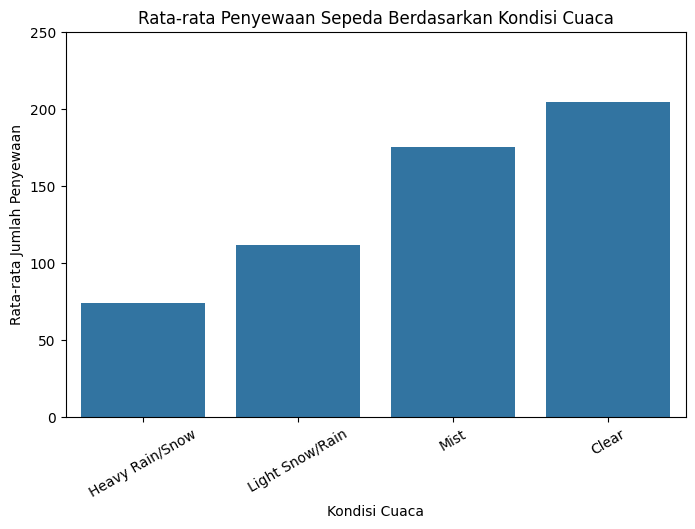

In [22]:
# membuat visualisasi diagram batang #
weather_usage = df_hour_clean.groupby('weathersit')['cnt'].mean().reset_index()

weather_usage = weather_usage.sort_values(by='cnt')

plt.figure(figsize=(8,5))
sns.barplot(data=weather_usage, x='weathersit', y='cnt')

plt.ylim(0, 250)

plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Kondisi Cuaca')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Rata-rata Jumlah Penyewaan')
plt.xticks(rotation=30)
plt.show()

**Insight:**
- Berdasarkan hasil visualisasi, kondisi cuaca memiliki dampak yang signifikan terhadap jumlah penyewaan sepeda. Terlihat bahwa rata-rata penyewaan tertinggi terjadi pada kondisi cuaca cerah (Clear) dengan jumlah sekitar 204 penyewaan. Sementara itu, pada kondisi berkabut (Mist), jumlah penyewaan menurun menjadi sekitar 175. Penurunan yang lebih besar terlihat pada kondisi hujan ringan atau salju ringan (Light Snow/Rain) dengan rata-rata sekitar 111 penyewaan, dan mencapai titik terendah pada kondisi hujan atau salju lebat (Heavy Rain/Snow) dengan rata-rata sekitar 74 penyewaan.

- Jika dibandingkan, terjadi penurunan lebih dari 60% dari kondisi cuaca cerah ke kondisi cuaca ekstrem. Hal ini menunjukkan bahwa semakin buruk kondisi cuaca, semakin rendah minat pengguna untuk menyewa sepeda.

- Dengan demikian, dapat disimpulkan bahwa kondisi cuaca memiliki pengaruh yang kuat terhadap permintaan penyewaan sepeda, dan permintaan tertinggi terjadi pada kondisi cuaca cerah selama periode pengamatan.

### Pertanyaan 2: Kapan periode waktu dengan permintaan penyewaan sepeda tertinggi berdasarkan jam, serta bagaimana pola ini dapat dimanfaatkan untuk meningkatkan efisiensi operasional?

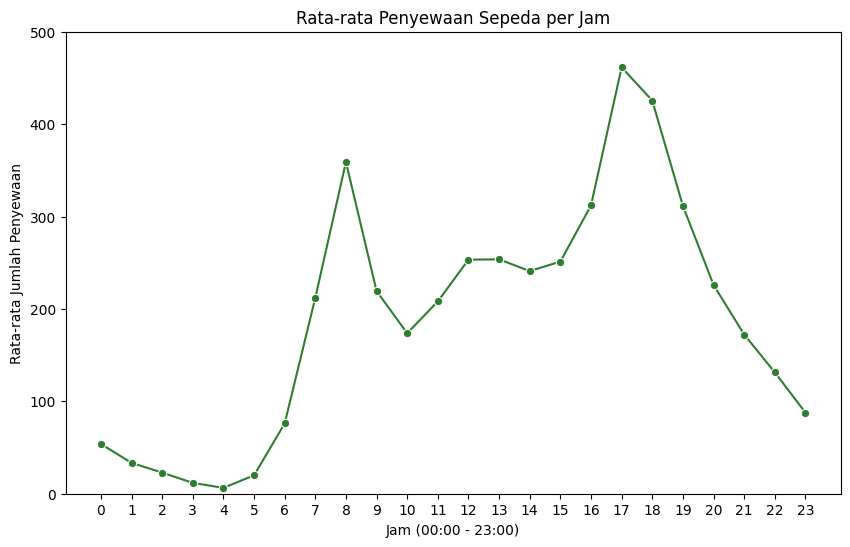

In [23]:
# membuat visualisasi diagram garis #
hourly = df_hour_clean.groupby('hr')['cnt'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(
    data=hourly,
    x="hr",
    y="cnt",
    marker="o",
    color="#2E7D32",
    ax=ax
)

ax.set_ylim(0, 500)
ax.set_xticks(range(0, 24))
ax.set_title('Rata-rata Penyewaan Sepeda per Jam')
ax.set_xlabel('Jam (00:00 - 23:00)')
ax.set_ylabel('Rata-rata Jumlah Penyewaan')

plt.show()
plt.close(fig)

**Insight:**
- Berdasarkan visualisasi rata-rata penyewaan sepeda per jam, terlihat bahwa permintaan tertinggi terjadi pada sore hari, khususnya sekitar pukul 17.00 hingga 18.00, dengan jumlah penyewaan mencapai lebih dari 400. Selain itu, terdapat puncak kedua pada pagi hari sekitar pukul 08.00 dengan jumlah penyewaan yang juga cukup tinggi dibandingkan jam lainnya.

- Pola ini menunjukkan adanya dua periode sibuk utama dalam sehari, yaitu pada jam berangkat kerja (pagi) dan jam pulang kerja (sore). Sementara itu, pada dini hari hingga pagi awal (sekitar pukul 00.00–05.00), jumlah penyewaan sangat rendah, yang menunjukkan minimnya aktivitas pengguna pada waktu tersebut.

- Pola ini dapat dimanfaatkan untuk meningkatkan efisiensi operasional dengan mengoptimalkan distribusi sepeda pada jam-jam sibuk, khususnya di pagi dan sore hari. Selain itu, perusahaan dapat menjadwalkan perawatan sepeda atau redistribusi armada pada jam-jam dengan permintaan rendah untuk menghindari gangguan pada periode sibuk.

### Pertanyaan 3: Berapa perbandingan total penyewaan sepeda antara hari kerja dan hari libur?

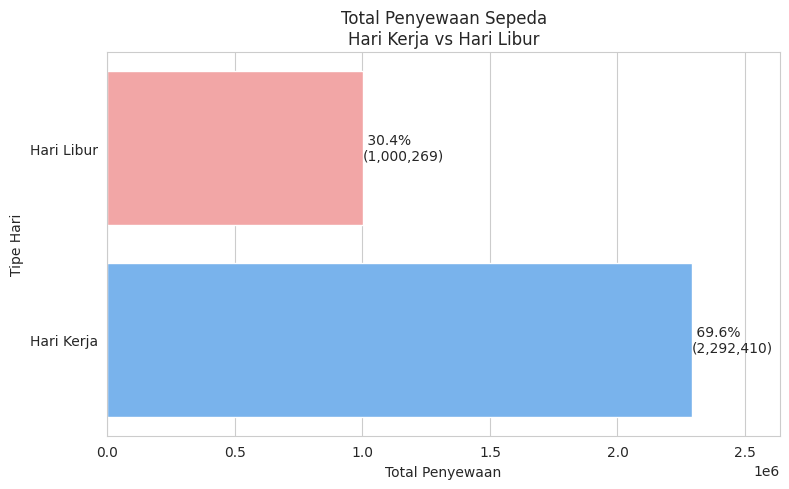

In [24]:
# membuat visualisai diagram batang horizontal #
grouped = df_day_clean.groupby('workingday')['cnt'].sum().reset_index()

label_mapping = {
    0: 'Hari Libur',
    1: 'Hari Kerja',
    'No': 'Hari Libur',
    'Yes': 'Hari Kerja'
}

grouped['workingday'] = grouped['workingday'].map(label_mapping)

grouped = grouped.dropna()
grouped['cnt'] = pd.to_numeric(grouped['cnt'], errors='coerce')

total = grouped['cnt'].sum()
grouped['percentage'] = (grouped['cnt'] / total) * 100

plt.figure(figsize=(8,5))
sns.set_style("whitegrid")

ax = sns.barplot(
    data=grouped,
    y='workingday',
    x='cnt',
    hue='workingday',
    palette=['#ff9999', '#66b3ff'],
    legend=False
)

for i, row in grouped.iterrows():
    ax.text(
        row['cnt'],
        i,
        f" {row['percentage']:.1f}%\n({int(row['cnt']):,})",
        va='center'
    )

plt.title('Total Penyewaan Sepeda\nHari Kerja vs Hari Libur')
plt.xlabel('Total Penyewaan')
plt.ylabel('Tipe Hari')

plt.xlim(0, grouped['cnt'].max() * 1.15)

plt.tight_layout()
plt.show()

**Insight:**
- Berdasarkan visualisasi, total penyewaan sepeda pada hari kerja jauh lebih tinggi dibandingkan hari libur. Hari kerja menyumbang sekitar 69.6% dari total penyewaan dengan jumlah sekitar 2.29 juta, sedangkan hari libur hanya sekitar 30.4% atau sekitar 1 juta penyewaan.

- Perbedaan ini menunjukkan bahwa mayoritas pengguna memanfaatkan sepeda sebagai sarana transportasi pada hari kerja, kemungkinan untuk aktivitas seperti bekerja atau sekolah. Sementara itu, penggunaan pada hari libur cenderung lebih rendah karena aktivitas commuting berkurang.

- Dengan demikian, dapat disimpulkan bahwa permintaan penyewaan sepeda lebih didominasi oleh hari kerja dibandingkan hari libur.

### Pertanyaan 4: Bagaimana komposisi profil pengguna pada sistem ini, dan sejauh mana perbedaan kontribusi antara pengguna terdaftar (registered) dibandingkan pengguna umum (casual) terhadap total penyewaan?

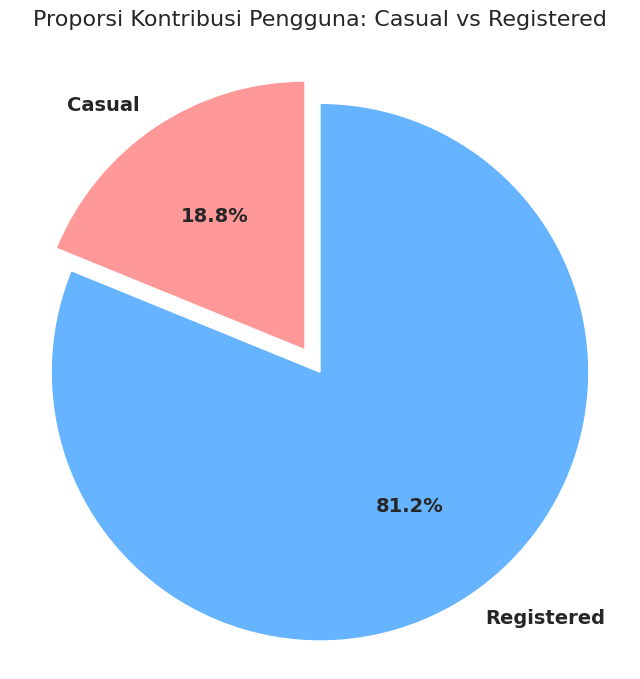

In [25]:
# Membuat visualisasi diagram pie #
total_casual = df_day_clean['casual'].sum()
total_registered = df_day_clean['registered'].sum()

counts = [total_casual, total_registered]
labels = ['Casual', 'Registered']
colors = ['#ff9999', '#66b3ff']

plt.figure(figsize=(8, 8))
plt.pie(
    counts,
    labels=labels,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    explode=(0.1, 0),
    textprops={'fontsize': 14, 'fontweight': 'bold'}
)

plt.title('Proporsi Kontribusi Pengguna: Casual vs Registered', fontsize=16, pad=20)
plt.axis('equal')
plt.show()

**Insight:**
- Berdasarkan visualisasi, komposisi pengguna pada sistem didominasi oleh pengguna terdaftar (registered) dengan kontribusi sebesar 81.2% dari total penyewaan sepeda. Sementara itu, pengguna umum (casual) hanya menyumbang sekitar 18.8%.

- Perbedaan ini menunjukkan bahwa sebagian besar penyewaan sepeda berasal dari pengguna yang telah terdaftar, yang kemungkinan menggunakan layanan secara rutin. Sebaliknya, pengguna casual cenderung menggunakan sepeda secara sesekali atau untuk kebutuhan rekreasi.

- Dengan demikian, dapat disimpulkan bahwa kontribusi pengguna registered jauh lebih besar dibandingkan pengguna casual, dengan selisih lebih dari 60%, yang mengindikasikan bahwa sistem bike sharing ini lebih banyak dimanfaatkan sebagai sarana transportasi harian daripada sekadar penggunaan sesaat.

## Analisis Lanjutan (Opsional)

In [26]:
# mengelompokkan jumlah penggunaan (cnt) ke dalam 3 level #
df_day_clean['usage_level'] = pd.cut(
    df_day_clean['cnt'],
    bins=[0, 2000, 4000, 7000],
    labels=['Low', 'Medium', 'High']
)
usage_dist = df_day_clean['usage_level'].value_counts().reset_index()
usage_dist.columns = ['usage_level', 'count']

usage_dist


,usage_level,count
0,High,358
1,Medium,181
2,Low,98


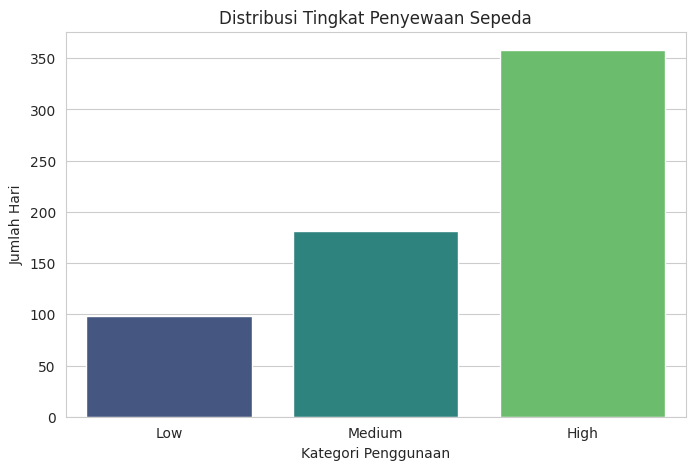

In [27]:
# visualisasi diagram batang #
plt.figure(figsize=(8,5))

sns.barplot(
    data=usage_dist,
    x='usage_level',
    y='count',
    hue='usage_level',
    palette='viridis',
    legend=False
)

plt.title('Distribusi Tingkat Penyewaan Sepeda')
plt.xlabel('Kategori Penggunaan')
plt.ylabel('Jumlah Hari')

plt.show()

## Conclusion

- Berdasarkan hasil segmentasi menggunakan teknik binning, mayoritas hari berada pada kategori penyewaan tinggi (High), yaitu sebanyak 358 hari atau lebih dari setengah total observasi.
Hal ini menunjukkan bahwa permintaan terhadap sepeda cenderung tinggi secara konsisten selama periode pengamatan.
Sementara itu, kategori medium dan rendah memiliki proporsi yang lebih kecil, yang mengindikasikan bahwa hari dengan permintaan rendah relatif jarang terjadi.